> **Solution version** -- this notebook contains the complete code of all exercises, executed from top to bottom, and answer elements for each observation question. The student version is available on the course webpage.


# PAC-Bayes 5 -- Linear classifiers, SVM and kernels as majority votes

A linear classifier $\mathrm{sign}\langle\mathbf w,x\rangle$ can be seen as the majority vote of an *infinite* ensemble: the linear classifiers $\mathrm{sign}\langle\mathbf v,x\rangle$ with
$\mathbf v\sim Q_{\mathbf w}=\mathcal N(\mathbf w,I)$. With the prior $P=\mathcal N(0,I)$ everything is explicit (lecture notes, Section 7.4): $\mathrm{KL}(Q_{\mathbf w}\|P)=\|\mathbf w\|^2/2$ and the Gibbs risk is a *probit* loss of the normalized margin.
We use this to certify SVMs, to learn linear classifiers by minimizing a bound (PBGD, Germain et al., 2009), and finally we look at kernels through random Fourier features.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

rng = np.random.RandomState(0)

def kl_bin(q, p):
    p = min(max(p, 1e-12), 1 - 1e-12)
    t1 = q * np.log(q / p) if q > 0 else 0.0
    t2 = (1 - q) * np.log((1 - q) / (1 - p)) if q < 1 else 0.0
    return t1 + t2

def kl_inv_upper(q, eps, tol=1e-9):
    lo, hi = q, 1.0
    while hi - lo > tol:
        mid = (lo + hi) / 2
        if kl_bin(q, mid) > eps: hi = mid
        else: lo = mid
    return hi

def seeger(emp, KL, m, delta=0.05):
    return kl_inv_upper(emp, (KL + np.log(2 * np.sqrt(m) / delta)) / m)

# data: standardized breast cancer, with a constant feature to have a bias
X, y = load_breast_cancer(return_X_y=True); y = 2 * y - 1
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
sc = StandardScaler().fit(Xtr)
add1 = lambda A: np.hstack([sc.transform(A), np.ones((len(A), 1))])
Xtr, Xte = add1(Xtr), add1(Xte)
m, d = Xtr.shape
print(m, d)

398 31



## I. The Gibbs risk of a Gaussian posterior

For $\mathbf v\sim\mathcal N(\mathbf w,I)$, $y\langle\mathbf v,x\rangle\sim\mathcal N(y\langle\mathbf w,x\rangle,\|x\|^2)$, so the probability that a random voter errs on $(x,y)$ is $\Phi\big(-y\langle\mathbf w,x\rangle/\|x\|\big)$.
Below, a Monte Carlo estimate of the empirical Gibbs risk for $\mathbf w$ given by a linear SVM.


In [2]:
svm = LinearSVC(C=1.0, fit_intercept=False, max_iter=20000).fit(Xtr, ytr)
w_svm = svm.coef_.ravel()

def gibbs_risk_mc(w, X, y, n_samples=2000):
    Vs = w + rng.randn(n_samples, len(w))                  # voters v ~ N(w, I)
    return np.mean(np.sign(X @ Vs.T) != y[:, None])

print(f"||w_svm|| = {np.linalg.norm(w_svm):.2f}, empirical risk of the SVM = {np.mean(np.sign(Xtr @ w_svm) != ytr):.3f}")
print(f"Monte Carlo Gibbs risk = {gibbs_risk_mc(w_svm, Xtr, ytr):.3f}")

||w_svm|| = 3.06, empirical risk of the SVM = 0.010
Monte Carlo Gibbs risk = 0.234



### Exercise 1

Write `gibbs_risk(w, X, y)` implementing the closed form $\frac1m\sum_i\Phi\big(-y_i\langle\mathbf w,x_i\rangle/\|x_i\|\big)$ and check it against the Monte Carlo estimate
for $\mathbf w_{\text{svm}}$, $3\mathbf w_{\text{svm}}$ and a random $\mathbf w$ (absolute tolerance $0.01$).


In [3]:
def gibbs_risk(w, X, y):
    return np.mean(norm.cdf(-y * (X @ w) / np.linalg.norm(X, axis=1)))

for w in [w_svm, 3 * w_svm, rng.randn(d)]:
    a, b = gibbs_risk(w, Xtr, ytr), gibbs_risk_mc(w, Xtr, ytr, 4000)
    print(f"closed form {a:.4f}   Monte Carlo {b:.4f}")
    np.testing.assert_allclose(a, b, atol=0.01)

closed form 0.2340   Monte Carlo 0.2376
closed form 0.0629   Monte Carlo 0.0630
closed form 0.5550   Monte Carlo 0.5608



## II. A risk certificate for the SVM direction

The majority vote of $Q_{s\mathbf u}$ is $\mathrm{sign}\langle\mathbf u,x\rangle$ for **every** scale $s>0$, but the Gibbs risk and the KL depend on $s$. Since the bound holds for all posteriors, we can scan $s$ and keep the best certificate
for the Gibbs classifier, which gives a certificate for the vote through $R(B_Q)\leq 2R(G_Q)$.


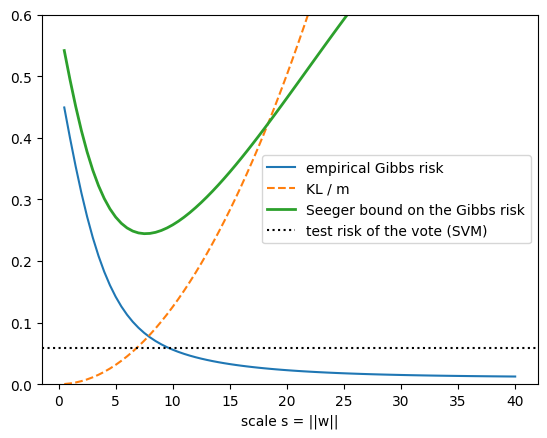

best scale 7.5: Gibbs bound 0.244, vote certificate 2 x bound = 0.489, test Gibbs 0.105


In [4]:
u = w_svm / np.linalg.norm(w_svm)
scales = np.linspace(0.5, 40, 80)
emp_g = [gibbs_risk(s * u, Xtr, ytr) for s in scales]
kls = [s**2 / 2 for s in scales]
bnd = [seeger(e, k, m) for e, k in zip(emp_g, kls)]
plt.plot(scales, emp_g, label="empirical Gibbs risk")
plt.plot(scales, np.array(kls) / m, "--", label="KL / m")
plt.plot(scales, bnd, lw=2, label="Seeger bound on the Gibbs risk")
plt.axhline(np.mean(np.sign(Xte @ u) != yte), color="k", ls=":", label="test risk of the vote (SVM)")
plt.ylim(0, 0.6); plt.xlabel("scale s = ||w||"); plt.legend(); plt.show()
i = int(np.argmin(bnd))
print(f"best scale {scales[i]:.1f}: Gibbs bound {bnd[i]:.3f}, vote certificate 2 x bound = {2 * bnd[i]:.3f}, "
      f"test Gibbs {gibbs_risk(scales[i] * u, Xte, yte):.3f}")

$$ $$

**Question 1:** Explain the shape of the curves: why does the empirical Gibbs risk decrease with the scale, and why does the bound increase for large scales? What plays the role of the *margin* here?

$$ $$

*Answer elements.* When the scale grows, the random voters $\mathbf v=s\mathbf u+\varepsilon$ get closer (in direction) to $\mathbf u$, so they agree with the vote on more points: $\Phi(-s\,y\langle\mathbf u,x\rangle/\|x\|)$ tends to $0$ on the well-classified points, the faster the larger the normalized margin $y\langle\mathbf u,x\rangle/\|x\|$. But the KL grows as $s^2/2$. Points with a large normalized margin allow a small $s$, hence a small KL: the certificate is good when the classifier has a large margin, which is the PAC-Bayesian explanation of SVM margin bounds (Langford & Shawe-Taylor, 2002).


## III. Learning by minimizing the bound: PBGD

Catoni's bound suggests to minimize $F(\mathbf w)=C\sum_i\Phi\big(-y_i\langle\mathbf w,x_i\rangle/\|x_i\|\big)+\frac12\|\mathbf w\|^2$, i.e. an SVM where the hinge loss is replaced by the probit loss (Germain et al., 2009).
As a model, here is the same kind of hand-written objective for the (regularized) logistic regression $C\sum_i\ln(1+e^{-y_i\langle\mathbf w,x_i\rangle})+\frac12\|\mathbf w\|^2$ with its gradient.


In [5]:
def logreg_obj(w, X, y, Creg):
    z = y * (X @ w)
    val = Creg * np.sum(np.logaddexp(0, -z)) + 0.5 * w @ w
    grad = -Creg * X.T @ (y * (1 / (1 + np.exp(z)))) + w
    return val, grad

w_lr = minimize(logreg_obj, np.zeros(d), args=(Xtr, ytr, 1.0), jac=True, method="L-BFGS-B").x
print("logistic regression: test risk", np.mean(np.sign(Xte @ w_lr) != yte))

logistic regression: test risk 0.023391812865497075



### Exercise 2

Implement `pbgd_obj(w, X, y, Creg)` (value and gradient; $\frac{d}{dt}\Phi(t)=\varphi(t)$, the Gaussian density), minimize it with L-BFGS starting from $\mathbf w_{\text{svm}}$ for
$C\in\{0.01, 0.1, 1, 10, 100\}$, and report for each value: $\|\mathbf w\|$, the empirical Gibbs risk, the Seeger bound on the Gibbs risk, the test Gibbs risk and the test risk of the vote. Compare with the SVM.
Do we need a union bound over the values of $C$?


In [6]:
nx_tr = np.linalg.norm(Xtr, axis=1)

def pbgd_obj(w, X, y, Creg, nx):
    t = -y * (X @ w) / nx
    val = Creg * np.sum(norm.cdf(t)) + 0.5 * w @ w
    grad = Creg * X.T @ (norm.pdf(t) * (-y / nx)) + w
    return val, grad

for Creg in [0.01, 0.1, 1, 10, 100]:
    w = minimize(pbgd_obj, w_svm, args=(Xtr, ytr, Creg, nx_tr), jac=True, method="L-BFGS-B").x
    e = gibbs_risk(w, Xtr, ytr); b = seeger(e, w @ w / 2, m)
    print(f"C={Creg:6.2f}  ||w||={np.linalg.norm(w):5.2f}  emp Gibbs {e:.3f}  bound {b:.3f}  "
          f"test Gibbs {gibbs_risk(w, Xte, yte):.3f}  test vote {np.mean(np.sign(Xte @ w) != yte):.3f}")
print(f"SVM: test vote {np.mean(np.sign(Xte @ w_svm) != yte):.3f}")

C=  0.01  ||w||= 0.76  emp Gibbs 0.343  bound 0.434  test Gibbs 0.346  test vote 0.117
C=  0.10  ||w||= 2.51  emp Gibbs 0.127  bound 0.213  test Gibbs 0.143  test vote 0.099
C=  1.00  ||w||= 5.02  emp Gibbs 0.054  bound 0.152  test Gibbs 0.073  test vote 0.047
C= 10.00  ||w||= 9.93  emp Gibbs 0.026  bound 0.201  test Gibbs 0.045  test vote 0.029
C=100.00  ||w||=20.51  emp Gibbs 0.013  bound 0.459  test Gibbs 0.038  test vote 0.035
SVM: test vote 0.058


*Answer elements.* Small $C$ gives a small $\|\mathbf w\|$ (small KL) but a large Gibbs risk (the random voters are almost random), large $C$ the opposite; the best certificate is obtained for an intermediate value ($C=1$ here, bound $\approx 0.15$), and the corresponding vote is as accurate as the SVM. No union bound is needed: $C$ only indexes posteriors $Q_{\mathbf w}$, and Seeger's bound holds for all of them simultaneously. A union bound would be needed if we had tuned the *prior* (e.g. its variance) on the data.


## IV. (Master) A data-dependent prior

The prior $\mathcal N(0,I)$ is far from any good classifier, so the KL is large. Following Ambroladze et al. (2006) and Parrado-Hernández et al. (2012), we can learn the **centre of the prior** on a part $S_1$ of the sample,
and compute the bound on the other part $S_2$ only: $\mathrm{KL}(\mathcal N(\mathbf w,I)\|\mathcal N(\mathbf w_0,I))=\|\mathbf w-\mathbf w_0\|^2/2$.
Here is the certificate of the posterior centred on the prior itself ($\mathbf w=\mathbf w_0$, KL $=0$) for a few scales of $\mathbf w_0$.


In [7]:
X1, X2, y1, y2 = train_test_split(Xtr, ytr, test_size=0.5, random_state=1)
u0 = LinearSVC(C=1.0, fit_intercept=False, max_iter=20000).fit(X1, y1).coef_.ravel()
u0 /= np.linalg.norm(u0)
m2 = len(y2)
for s in [2, 5, 10, 20]:
    e = gibbs_risk(s * u0, X2, y2)
    print(f"w = w0 = {s} u0: emp Gibbs on S2 {e:.3f}, bound {seeger(e, 0.0, m2):.3f}")

w = w0 = 2 u0: emp Gibbs on S2 0.301, bound 0.424
w = w0 = 5 u0: emp Gibbs on S2 0.145, bound 0.248
w = w0 = 10 u0: emp Gibbs on S2 0.076, bound 0.161
w = w0 = 20 u0: emp Gibbs on S2 0.052, bound 0.128



### Exercise 3

With the prior $\mathcal N(s_0\mathbf u_0,I)$ (choose $s_0$ on a grid of 5 values **with a union bound**, i.e. $\delta/5$ for each), run PBGD on $S_2$ with the KL term $\|\mathbf w-s_0\mathbf u_0\|^2/2$ and a grid of $C$.
Report the best certificate and compare it with Section III. Is splitting the sample worth it here?


In [8]:
nx2 = np.linalg.norm(X2, axis=1)
def pbgd_prior_obj(w, X, y, Creg, nx, w0):
    t = -y * (X @ w) / nx
    val = Creg * np.sum(norm.cdf(t)) + 0.5 * (w - w0) @ (w - w0)
    grad = Creg * X.T @ (norm.pdf(t) * (-y / nx)) + (w - w0)
    return val, grad

s_grid = [2, 5, 10, 20, 40]
best = (1.0, None)
for s0 in s_grid:
    w0 = s0 * u0
    for Creg in [0.1, 1, 10, 100]:
        w = minimize(pbgd_prior_obj, w0, args=(X2, y2, Creg, nx2, w0), jac=True, method="L-BFGS-B").x
        e = gibbs_risk(w, X2, y2)
        b = seeger(e, (w - w0) @ (w - w0) / 2, m2, delta=0.05 / len(s_grid))
        if b < best[0]:
            best = (b, (s0, Creg, gibbs_risk(w, Xte, yte), np.mean(np.sign(Xte @ w) != yte)))
print(f"best certificate {best[0]:.3f} with (s0, C, test Gibbs, test vote) = {best[1]}")

best certificate 0.125 with (s0, C, test Gibbs, test vote) = (20, 1, np.float64(0.07113271638124946), np.float64(0.07017543859649122))


*Answer elements.* The data-dependent prior reduces the KL dramatically (the posterior stays close to a good prior), which compensates the halved sample size: the certificate is tighter than with $\mathcal N(0,I)$ (about $0.125$ vs $0.15$ here), although the vote itself, learned on half of the data, is slightly less accurate. The union bound over the 5 scales costs only $\ln 5$. The gain is larger for bigger datasets and higher dimensions, where the KL to $\mathcal N(0,I)$ is the dominant term.


## V. Kernels as priors: random Fourier features

For the Gaussian kernel $k(x,x')=e^{-\gamma\|x-x'\|^2}$, Bochner's theorem gives $k(x,x')=\mathbb E_{\omega\sim\mathcal N(0,2\gamma I)}\cos(\omega^\top(x-x'))$: the kernel is the **vote under the prior** $p(\omega)$ of the voters $h_\omega(x,x')=\cos(\omega^\top(x-x'))$ (Letarte et al., 2019).
Here we build a simple ensemble of binary voters $h_{\omega,b}(x)=\mathrm{sign}\cos(\omega^\top x+b)$ and their opposites, with $\omega\sim\mathcal N(0,2\gamma I)$, $b\sim\mathcal U[0,2\pi]$, and learn a Gibbs posterior over them on the `moons` dataset. We use half of the training set as a hold-out to compute the first-order certificate.


In [9]:
Xm, ym = make_moons(1500, noise=0.25, random_state=0); ym = 2 * ym - 1
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.4, random_state=0)
gamma, N = 5.0, 2000
W = rng.normal(0, np.sqrt(2 * gamma), (N, 2)); b = rng.uniform(0, 2 * np.pi, N)
def rff_votes(X):
    H = np.sign(np.cos(X @ W.T + b)).T
    return np.vstack([H, -H])                          # self-complemented set of 2N voters
V_tr, V_te = rff_votes(Xm_tr), rff_votes(Xm_te)
emp = (V_tr != ym_tr).mean(1)
P = np.ones(2 * N) / (2 * N)
mtr = len(ym_tr)
for lam in [0.001, 0.005, 0.02, 0.1, 0.5]:
    logw = np.log(P) - lam * mtr * emp; rho = np.exp(logw - logw.max()); rho /= rho.sum()
    KL = np.sum(rho * np.log(rho / P))
    print(f"lambda={lam:5.3f}  KL={KL:5.2f}  emp Gibbs {rho @ emp:.3f}  Seeger {seeger(rho @ emp, KL, mtr):.3f}  "
          f"test vote {np.mean(np.where(rho @ V_te >= 0, 1, -1) != ym_te):.3f}")
print("RBF SVM test risk:", np.mean(SVC(gamma=gamma).fit(Xm_tr, ym_tr).predict(Xm_te) != ym_te))

lambda=0.001  KL= 0.01  emp Gibbs 0.488  Seeger 0.551  test vote 0.065
lambda=0.005  KL= 0.14  emp Gibbs 0.439  Seeger 0.502  test vote 0.073
lambda=0.020  KL= 2.18  emp Gibbs 0.250  Seeger 0.315  test vote 0.110
lambda=0.100  KL= 5.40  emp Gibbs 0.150  Seeger 0.215  test vote 0.135
lambda=0.500  KL= 6.81  emp Gibbs 0.141  Seeger 0.209  test vote 0.133
RBF SVM test risk: 0.06333333333333334


$$ $$

**Question 2:** How does the test risk of the vote evolve with $\lambda$? Compare with the RBF SVM. Why is the empirical Gibbs risk still high even when the vote is good?

$$ $$

*Answer elements.* Surprisingly, the vote is best for a *very small* $\lambda$, i.e. for a posterior which is almost the prior: since the set of voters is self-complemented, $\sum_\omega\rho(\omega)h_\omega(x)\approx\lambda m\sum_\omega P(\omega)\big(\hat R(-h_\omega)-\hat R(h_\omega)\big)h_\omega(x)$, which is a kernel-type classifier built from all the random features, and it is competitive with the RBF SVM. Larger $\lambda$ concentrate the posterior on a few features: the Gibbs risk and the first-order certificate improve, but the vote loses its diversity and gets worse. Each individual voter is a weak classifier (a random periodic partition of the plane), so the Gibbs risk stays high and $2R(G)$ is useless to certify the vote: second-order bounds, or the kernel-alignment bounds of Letarte et al. (2019), are needed.


## Conclusion

Linear classifiers and kernel machines fit naturally in the PAC-Bayesian framework: Gaussian posteriors give explicit KL and Gibbs risk, the SVM objective is recovered as a bound minimization,
and kernels can be seen as priors over voters. Data-dependent priors are the key to tight certificates.
